In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.shape

(768, 9)

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
(df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Outcome', 'Pregnancies']] == 0).sum() 

Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
Age                           0
DiabetesPedigreeFunction      0
Outcome                     500
Pregnancies                 111
dtype: int64

In this diabetes dataset, at first glance it would seem there were no missing values, but we find a good amount of cells with value 0. These values were treated as missing data for all other columns except Pregnancies and Outcome which are on/off indicators. In the other columns like Insulin, BloodPressure etc., 0 is an impossible value for a living human. Hence they were considered as missing values. This demonstrated to me the importance of domain knowledge.

Dropping these rows are not an option as they make up almost half of the record in the dataset and would lead to a data loss.

Filling is the better option. Whether with mean or median could only be decided after observing the nature of their distribution.

In [8]:
#Replacing 0 values with Nan and checking the nature of distribution for these columns

cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)


df[cols_to_fix].skew()

Glucose          0.530989
BloodPressure    0.134153
SkinThickness    0.690619
Insulin          2.166464
BMI              0.593970
dtype: float64

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002AEB07F1548>,
      dtype=object)

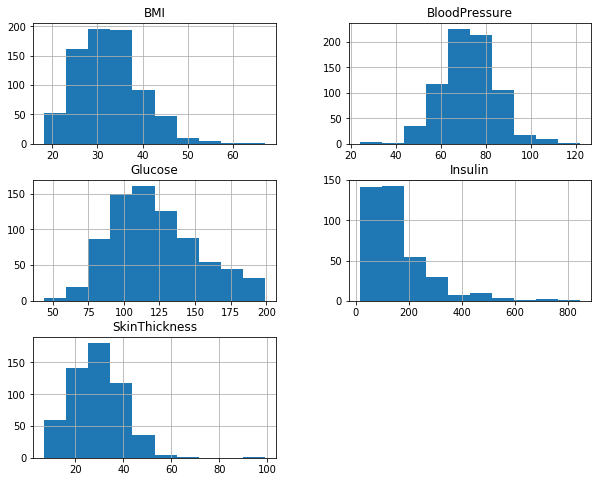

In [9]:
df[cols_to_fix].hist(figsize=(10,8))

Based on the skew results and diagrams illustrating the (a)symmetry of these columns, the following filling decisions were adopted:

BloodPessure (0.13) and Glucose (0.53) >> approximately symmetric >> mean
SkinThickness (0.69) and BMI (0.60) >> slightly assymetric >> median
Insulin (2.17) >> evidently assymetric >> median

Note: Skew values of -0.5 to 0.5 indicates approximate symmetry while <-1.0 or > 1.0 indicates high asymmetry/skewness

The median is chosen in case of asymmetry because filing with the mean would pull averages towards outliers or the direction of asymmetry. The mean would be a good approximation for missing values in the case of assymetry.


In [10]:
mean_cols = ['BloodPressure', 'Glucose']
median_cols = ['SkinThickness', 'BMI', 'Insulin', ]

for col in mean_cols:
    df[col] = df[col].fillna(df[col].mean())
    
for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

In [11]:
#Confirming that null values have been correctly mitigated


df[cols_to_fix].isnull().sum()


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Limitation: Median was imputed to 374 rows (about 49%) of insulin records. While this preserves the central tendency, it compresses the interquartile range and may affect the models variance.

In [13]:
df[cols_to_fix].dtypes

Glucose          float64
BloodPressure    float64
SkinThickness    float64
Insulin          float64
BMI              float64
dtype: object

In [14]:
df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [15]:
#Seperating target from features

X = df.drop('Outcome', axis = 1)
y = df['Outcome']

#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Logistic regression model (untuned)
baseline_model = LogisticRegression(max_iter = 1000)
baseline_model.fit(X_train, y_train)

#Predicting
y_pred = baseline_model.predict(X_test)

#Accuracy score
baseline_accuracy = accuracy_score(y_test, y_pred)
print (baseline_accuracy)

0.7532467532467533


In [16]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform (X_train)
X_test_scaled = sc.transform (X_test)

In [17]:
baseline_model_scaled = LogisticRegression(max_iter = 1000)
baseline_model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = baseline_model_scaled.predict(X_test_scaled)


scaled_accuracy = accuracy_score(y_test, y_pred_scaled)
print (scaled_accuracy)

0.7532467532467533


No improvement in accuracy score (0.7532) was observed after scaling. This would mean that the unscaled model was still able to converge given the high iteration cap.

C is a parameter that determines regularisation strength. 
Larger C value means weaker regularisation, which also leads to high variance and low bias, hence more risk of overfitting.
Smaller C values means stronger regularisation, which may also lead to low variance, high bias and hence, underfitting risk.

Larger values mean the model is less penalised for big weights on some features while with smaller C values, heavy weighted features are more penalised.

In [18]:
param_grid = {'C':[0.01, 0.1, 1, 10, 100], 'penalty':['l2'], 'solver':['lbfgs']}

grid_search = GridSearchCV(LogisticRegression(max_iter = 1000), param_grid = param_grid, cv = 5, scoring = 'accuracy')

grid_search.fit(X_train_scaled, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.7687724910035986


In [19]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print (tuned_accuracy)

0.7532467532467533


The test accuracy of the tuned and scaled model matched exactly to the baseline model(0.7532). This is because the best parameters selected by GridSearchCV matched the default hyperparameters as used in the baseline model.

C = 1 was the default regularisation and was selected GridSearchCV.

In [20]:
# Evaluation scores

y_pred_base = baseline_model.predict(X_test)

#Scores for baseline model
base_precision = precision_score (y_test, y_pred_base)
base_recall = recall_score (y_test, y_pred_base)
base_f1 = f1_score (y_test, y_pred_base)
base_roc_auc = roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:,1])

#Scores for best_model
tuned_precision = precision_score (y_test, y_pred_tuned)
tuned_recall = recall_score (y_test, y_pred_tuned)
tuned_f1 = f1_score (y_test, y_pred_tuned)
tuned_roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:,1])

print("Baseline:", base_precision, base_recall, base_f1, base_roc_auc)
print("Tuned:", tuned_precision, tuned_recall, tuned_f1, tuned_roc_auc)

Baseline: 0.6666666666666666 0.6181818181818182 0.6415094339622642 0.8211202938475666
Tuned: 0.6666666666666666 0.6181818181818182 0.6415094339622642 0.8231404958677686


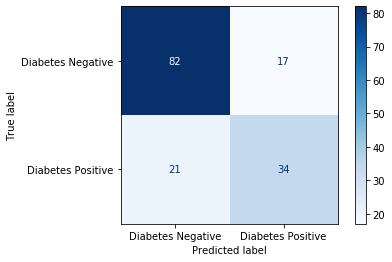

In [21]:


cm = confusion_matrix (y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Diabetes Negative', 'Diabetes Positive'] )
disp.plot(cmap = 'Blues')
plt.show()

In [22]:
table_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline': [0.7532, 0.6667, 0.6182, 0.6415, 0.8211],
    'Tuned': [0.7532, 0.6667, 0.6182, 0.6415, 0.8231],
}

comparison = pd.DataFrame(table_data)

comparison.style.hide_index()

Metric,Baseline,Tuned
Accuracy,0.753200,0.753200
Precision,0.666700,0.666700
Recall,0.618200,0.618200
F1-Score,0.641500,0.641500
ROC-AUC,0.821100,0.823100
